In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install shap

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/Thesis v3/2 Model/cnnlstm.keras')

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 51, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 51, 16)         │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 51, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 25, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 25, 16)         │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 16)         │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 25, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 12, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 12, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 294,584 (1.12 MB)

 Trainable params: 98,130 (383.32 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 196,262 (766.65 KB)

In [ ]:
import pandas as pd

df_train = pd.read_csv("/content/drive/MyDrive/Thesis v3/1 Extracted Features/df_train.csv")
#df_train

In [ ]:
df_test = pd.read_csv("/content/drive/MyDrive/Thesis v3/1 Extracted Features/df_test.csv")
#df_test

In [ ]:
import tensorflow as tf

In [ ]:
X = df_train.drop('audio_type', axis=1).values
y = df_train['audio_type'].values

# Encode categorical labels to numerical
from sklearn.preprocessing import LabelEncoder, StandardScaler
label_encoder = LabelEncoder()
y_numerical = label_encoder.fit_transform(y)

# One-hot encode numerical labels
y_one_hot = tf.keras.utils.to_categorical(y_numerical, num_classes=2)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check for NaN values in features
if np.isnan(X_scaled).any():
    print("Warning: NaN values found in scaled features (X_scaled). This can cause 'nan' loss during training.")
else:
    print("No NaN values found in scaled features (X_scaled).")

No NaN values found in scaled features (X_scaled).


In [ ]:
from sklearn.model_selection import KFold, train_test_split

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X_scaled, y_one_hot, test_size=0.1, random_state=42)

X_train_full = X_train_full.reshape(X_train_full.shape[0], 51, 1)
X_test = X_test.reshape(X_test.shape[0], 51, 1)

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

fold_no = 1
scores = []

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix

In [ ]:
print("\nTraining Final Model on full Training Set...")
final_model = model
final_model.fit(X_train_full, y_train_full, batch_size=32, epochs=30, verbose=0)

loss, accuracy = final_model.evaluate(X_test, y_test, verbose=0)

y_pred = np.argmax(final_model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"\n--- Final MIDs Results (Test Set) ---")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Sensitivity: {sensitivity*100:.2f}%")
print(f"Specificity: {specificity*100:.2f}%")


Training Final Model on full Training Set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 391ms/step

--- Final MIDs Results (Test Set) ---
Accuracy: 80.00%
Sensitivity: 77.27%
Specificity: 82.61%


In [ ]:
X_test_data = df_test.drop('audio_type', axis=1).values
y_test_data = df_test['audio_type'].values

# Encode categorical labels to numerical using the fitted label_encoder
y_numerical_test = label_encoder.transform(y_test_data)

# One-hot encode numerical labels
y_one_hot_test = tf.keras.utils.to_categorical(y_numerical_test, num_classes=2)

# Normalize features using the fitted scaler
X_scaled_test = scaler.transform(X_test_data)

# Reshape input to (Samples, 51, 1) for 1D CNN
X_scaled_test = X_scaled_test.reshape(X_scaled_test.shape[0], 51, 1)

# Evaluate the final model on the test data
loss_test, accuracy_test = final_model.evaluate(X_scaled_test, y_one_hot_test, verbose=0)

# Make predictions on the test data
y_pred_probs_test = final_model.predict(X_scaled_test)
y_pred_test = np.argmax(y_pred_probs_test, axis=1)
y_true_test = np.argmax(y_one_hot_test, axis=1)

# Compute the confusion matrix
conf_matrix_test = confusion_matrix(y_true_test, y_pred_test)
tn_test, fp_test, fn_test, tp_test = conf_matrix_test.ravel()

# Calculate Sensitivity and Specificity
sensitivity_test = tp_test / (tp_test + fn_test)
specificity_test = tn_test / (tn_test + fp_test)

print(f"\n--- Evaluation on df_test --- ")
print(f"Test Accuracy: {accuracy_test*100:.2f}%")
print(f"Test Sensitivity: {sensitivity_test*100:.2f}%")
print(f"Test Specificity: {specificity_test*100:.2f}%")
print(f"Confusion Matrix:\n{conf_matrix_test}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

--- Evaluation on df_test --- 
Test Accuracy: 75.00%
Test Sensitivity: 67.86%
Test Specificity: 82.14%
Confusion Matrix:
[[46 10]
 [18 38]]


In [ ]:
import shap

In [ ]:
def f(x):
    # Reshape the input x to (samples, 51, 1) as required by the model
    x_reshaped = x.reshape(x.shape[0], 51, 1)
    # Get the model's predictions (probabilities for each class)
    preds = final_model.predict(x_reshaped, verbose=0)
    # For binary classification, SHAP often works best with the probability of the positive class
    # Assuming the positive class is at index 1
    return preds[:, 1]

In [ ]:
background_data_2d = X_scaled[np.random.choice(X_scaled.shape[0], 100, replace=False)]
explainer = shap.KernelExplainer(f, background_data_2d)

In [ ]:
# full data
'''
X_scaled_test_reshaped = X_scaled_test.reshape(X_scaled_test.shape[0], X_scaled_test.shape[1])
shap_values = explainer.shap_values(X_scaled_test_reshaped)
'''

'\nX_scaled_test_reshaped = X_scaled_test.reshape(X_scaled_test.shape[0], X_scaled_test.shape[1])\nshap_values = explainer.shap_values(X_scaled_test_reshaped)\n'

In [ ]:
X_scaled_test_reshaped = X_scaled_test.reshape(X_scaled_test.shape[0], X_scaled_test.shape[1])
# Select only the first instance from the test data for explanation
one_instance_to_explain = X_scaled_test_reshaped[0:1]
shap_values = explainer.shap_values(one_instance_to_explain)

  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
shap_attributions = shap_values[0]

In [ ]:
def calculate_faithfulness(model, X_sample, attribution_values, top_k=5):
    """
    Measures how much the prediction drops when top_k features are masked.

    Returns:
        drop_score: (Original Prob - Perturbed Prob). Higher is better.
    """
    # Get original prediction
    # Reshape for keras (1, 51, 1)
    X_sample_reshaped = X_sample.reshape(1, 51, 1)
    original_prob = model.predict(X_sample_reshaped, verbose=0)[0][0]

    # Identify indices of the top_k most important features (absolute value)
    importance_scores = np.abs(attribution_values)
    top_indices = np.argsort(importance_scores)[-top_k:]

    # Create perturbed sample (Masking top features to 0)
    X_perturbed = X_sample.copy()
    X_perturbed[0, top_indices] = 0.0  # Or set to X_train.mean() if 0 isn't neutral

    # Reshape for keras (1, 51, 1)
    X_perturbed_reshaped = X_perturbed.reshape(1, 51, 1)
    perturbed_prob = model.predict(X_perturbed_reshaped, verbose=0)[0][0]

    # Calculate drop
    drop_score = original_prob - perturbed_prob
    return drop_score

In [ ]:
score_shap = calculate_faithfulness(model, one_instance_to_explain, shap_attributions, top_k=5)

In [ ]:
print(score_shap)

-0.9683737


In [ ]:
feature_names = df_train.drop('audio_type', axis=1).columns.tolist()
# Use KernelExplainer as GradientExplainer and DeepExplainer are failing with gradient errors
# The 'f' function and 'background_data_2d' were defined and used successfully earlier for KernelExplainer
explainer = shap.KernelExplainer(f, background_data_2d)

In [ ]:
instance_to_explain_index = 0
# x_to_explain was (1, 51, 1) but KernelExplainer's 'f' function expects (1, 51)
# So, reshape it for KernelExplainer
x_to_explain_2d = X_scaled_test[instance_to_explain_index:instance_to_explain_index+1].reshape(1, -1)
y_true_for_instance = y_true_test[instance_to_explain_index]

shap_values = explainer.shap_values(x_to_explain_2d) # Use the 2D version
expected_values = final_model.predict(X_train_full).mean(axis=0)

print(f"Explaining instance at index: {instance_to_explain_index}")
print(f"True label for this instance: {y_true_test[instance_to_explain_index]} ({label_encoder.inverse_transform([y_true_test[instance_to_explain_index]])[0]}) ")
predicted_probabilities = final_model.predict(X_scaled_test[instance_to_explain_index:instance_to_explain_index+1]) # Keep original for model prediction
print(f"Predicted probabilities: {predicted_probabilities}")
print("Expected values (mean model output on background data) calculated.")
print(f"Expected values for Class 0 (myocardial): {expected_values[0]:.4f}")
print(f"Expected values for Class 1 (normal): {expected_values[1]:.4f}")

  0%|          | 0/1 [00:00<?, ?it/s]

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Explaining instance at index: 0
True label for this instance: 0 (myocardial) 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted probabilities: [[0.03162306 0.96837693]]
Expected values (mean model output on background data) calculated.
Expected values for Class 0 (myocardial): 0.5011
Expected values for Class 1 (normal): 0.4989


In [ ]:
shap_attributions = shap_values[0]
score_ig = calculate_faithfulness(model, one_instance_to_explain, shap_attributions, top_k=5)
print(score_ig)

-0.9683761


In [ ]:
# DeepLIFT

# Reshape background data to (100, 51, 1)
background_data_dl = background_data_2d.reshape(background_data_2d.shape[0], 51, 1)

# Reshape the instance to explain to (1, 51, 1)
x_to_explain_dl = x_to_explain.reshape(1, 51, 1)

In [ ]:
# initialize DeepLIFT
# explainer_dl = shap.DeepExplainer(final_model, background_data_dl)


In [ ]:
# compute DeepLIFT value
# shap_values_dl = explainer_dl.shap_values(x_to_explain_dl)


In [ ]:
def model_predict_wrapper(x):
    # Reshape input for the CNN
    x_reshaped = x.reshape(x.shape[0], 51, 1)

    # Get predictions
    preds = final_model.predict(x_reshaped, verbose=0)

    # Return probabilities for the target class (Class 0 based on your logs)
    # If you want Class 1, change to preds[:, 1]
    return preds[:, 0]

In [ ]:
explainer_generic = shap.Explainer(model_predict_wrapper, background_data_2d)

In [ ]:
# The original x_to_explain has shape (1, 51, 1).
# The explainer_generic was built with background_data_2d of shape (100, 51),
# implying it expects 2D input features (num_samples, num_features).
# Therefore, x_to_explain needs to be reshaped to (1, 51) to match this expectation.
x_to_explain_2d = x_to_explain.reshape(1, -1)
explanation_obj = explainer_generic(x_to_explain_2d)

PermutationExplainer explainer: 2it [00:21, 21.68s/it]               


In [ ]:
attributions_generic = explanation_obj.values[0]

In [ ]:
score_shap_gen = calculate_faithfulness(final_model, x_to_explain, attributions_generic, top_k=5)

print(f"SHAP (Generic Explainer) Faithfulness Score: {score_shap_gen}")

SHAP (Generic Explainer) Faithfulness Score: -0.8448693156242371


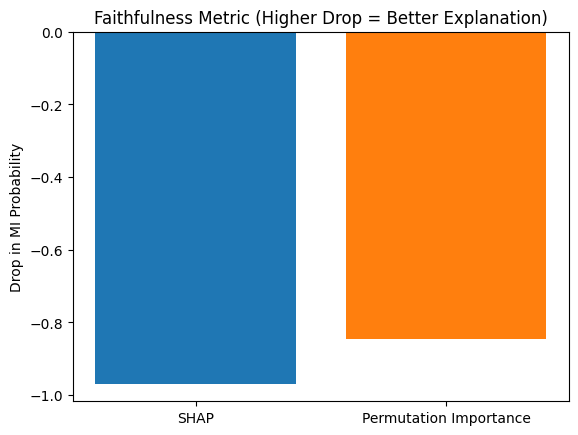

In [ ]:
'''
if score_shap > score_ig:
    print("\nWinner: SHAP is more faithful for this sample.")
else:
    print("\nWinner: Integrated Gradients is more faithful for this sample.")
'''

# Visualization
methods = ['SHAP', 'Permutation Importance']
scores = [score_shap, score_shap_gen]

plt.bar(methods, scores, color=['#1f77b4', '#ff7f0e'])
plt.ylabel('Drop in MI Probability')
plt.title('Faithfulness Metric (Higher Drop = Better Explanation)')
plt.show()